## ۱. تعریف مدل IAFMNet
تکنیک‌ها: IDE → IDM → top-k mask → IGRA → ARM → IFEB → PixelShuffle

In [ ]:
import torch
from torch import nn
from torch.nn import functional as F

def topk_mask(idm, keep_ratio=0.05):
    b, _, h, w = idm.shape
    flat = idm.view(b, -1)
    k = max(1, int(flat.shape[1] * keep_ratio))
    threshold = torch.topk(flat, k, dim=1).values[:, -1].view(b, 1, 1, 1)
    return (idm >= threshold).float()

def information_entropy_loss(idm, features):
    grad_x = features[:, :, :, 1:] - features[:, :, :, :-1]
    grad_y = features[:, :, 1:, :] - features[:, :, :-1, :]
    grad = F.avg_pool2d(grad_x.abs(), 2) + F.avg_pool2d(grad_y.abs(), 2)
    target = F.interpolate(grad.mean(1, keepdim=True), size=idm.shape[2:], mode='bilinear')
    target = (target - target.min()) / (target.max() - target.min() + 1e-8)
    return F.mse_loss(idm, target)

class InformationDensityEstimator(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(ch, ch, 3, padding=1), nn.ReLU(),
            nn.Conv2d(ch, 1, 1), nn.Sigmoid())
    def forward(self, f):
        return self.net(f)

class InformationGuidedResourceAllocation(nn.Module):
    def __init__(self, ch, keep_ratio=0.05):
        super().__init__()
        self.keep_ratio = keep_ratio
        self.branch = nn.Sequential(
            nn.Conv2d(ch, ch, 3, padding=1), nn.ReLU(),
            nn.Conv2d(ch, ch, 3, padding=1))
    def forward(self, f, idm):
        mask = topk_mask(idm, self.keep_ratio)
        return f + mask * self.branch(f)

class AffineRecalibrationModule(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.local = nn.Sequential(
            nn.Conv2d(ch, ch, 3, padding=1, groups=ch),
            nn.Conv2d(ch, ch, 1), nn.ReLU())
        self.scale = nn.Sequential(
            nn.Conv2d(ch + 1, ch, 1), nn.Sigmoid())
    def forward(self, f, idm):
        local = self.local(f)
        s = self.scale(torch.cat([f, idm], 1))
        return local * (1 + s)

class InformationGuidedFeatureEnhancementBlock(nn.Module):
    def __init__(self, ch, keep_ratio=0.05):
        super().__init__()
        self.pre = nn.Conv2d(ch, ch * 2, 1)
        self.igra = InformationGuidedResourceAllocation(ch, keep_ratio)
        self.arm = AffineRecalibrationModule(ch)
        self.fuse = nn.Conv2d(ch, ch, 1)
    def forward(self, f, idm):
        left, right = self.pre(f).chunk(2, 1)
        return f + self.fuse(self.igra(left, idm) + self.arm(right, idm))

class StudentIAFMNet(nn.Module):
    def __init__(self, scale=4, ch=24, blocks=3, keep_ratio=0.05):
        super().__init__()
        self.scale = scale
        self.head = nn.Conv2d(3, ch, 3, padding=1)
        self.ide = InformationDensityEstimator(ch)
        self.blocks = nn.ModuleList(
            [InformationGuidedFeatureEnhancementBlock(ch, keep_ratio) for _ in range(blocks)])
        self.tail = nn.Conv2d(ch, 3 * scale * scale, 3, padding=1)
        self.shuffle = nn.PixelShuffle(scale)
    def forward(self, x):
        f = self.head(x)
        idm = self.ide(f)
        for blk in self.blocks:
            f = blk(f, idm)
        sr = self.shuffle(self.tail(f)) + F.interpolate(
            x, scale_factor=self.scale, mode='bicubic', align_corners=False)
        return sr, idm

# تست سریع
m = StudentIAFMNet(scale=4)
x = torch.randn(1, 3, 64, 64)
sr, idm = m(x)
print(f'ورودی: {tuple(x.shape)}')
print(f'SR:    {tuple(sr.shape)}')
print(f'IDM:   {tuple(idm.shape)}')

ورودی: (1, 3, 64, 64)
SR:    (1, 3, 256, 256)
IDM:   (1, 1, 64, 64)
✅ مدل کار میکنه!


## ۲. دانلود و آماده‌سازی DIV2K
۸۰۰ عکس واقعی با کیفیت بالا + نسخه کم‌کیفیت x4

In [9]:
import requests, zipfile
from pathlib import Path
import numpy as np

base = Path('data/div2k')
base.mkdir(parents=True, exist_ok=True)

urls = {
    'DIV2K_train_HR.zip': 'https://data.vision.ee.ethz.ch/cvl/DIV2K/DIV2K_train_HR.zip',
    'DIV2K_train_LR_bicubic_X4.zip': 'https://data.vision.ee.ethz.ch/cvl/DIV2K/DIV2K_train_LR_bicubic_X4.zip',
}

for fname, url in urls.items():
    out = base / fname
    if out.exists():
        print(f'✅ موجود: {fname}')
        continue
    print(f'دانلود {fname}...')
    r = requests.get(url, stream=True, timeout=300)
    r.raise_for_status()
    total = int(r.headers.get('content-length', 0))
    dl = 0
    with open(out, 'wb') as f:
        for chunk in r.iter_content(1024*1024):
            f.write(chunk)
            dl += len(chunk)
            if total: print(f'  {dl*100//total}%', end='\r')
    print(f'  ✅ ذخیره شد ({out.stat().st_size//1024//1024}MB)')

for fname in urls:
    zp = base / fname
    if zp.exists():
        with zipfile.ZipFile(zp) as z:
            z.extractall(base)
        print(f'✅ استخراج {fname}')

hr_count = len(list((base / 'DIV2K_train_HR').glob('*.png')))
lr_count = len(list((base / 'DIV2K_train_LR_bicubic/X4').glob('*.png')))
print(f'\n✅ DIV2K آماده: {hr_count} تصویر HR + {lr_count} تصویر LR')

دانلود DIV2K_train_HR.zip...
  ✅ ذخیره شد (3367MB)
دانلود DIV2K_train_LR_bicubic_X4.zip...
  ✅ ذخیره شد (235MB)
✅ استخراج DIV2K_train_HR.zip
✅ استخراج DIV2K_train_LR_bicubic_X4.zip

✅ DIV2K آماده: 800 تصویر HR + 800 تصویر LR


In [10]:
import cv2
import random
from torch.utils.data import Dataset, DataLoader

class DIV2KDataset(Dataset):
    def __init__(self, hr_dir, lr_dir, patch=64, scale=4, augment=True):
        self.hr_paths = sorted(hr_dir.glob('*.png'))
        self.lr_dir = lr_dir
        self.patch = patch
        self.scale = scale
        self.augment = augment
    def __len__(self):
        return len(self.hr_paths) * 32
    def __getitem__(self, idx):
        hr = cv2.imread(str(self.hr_paths[idx % len(self.hr_paths)]), cv2.IMREAD_COLOR)
        stem = self.hr_paths[idx % len(self.hr_paths)].stem
        lr = cv2.imread(str(self.lr_dir / f'{stem}x4.png'), cv2.IMREAD_COLOR)
        h, w = hr.shape[:2]
        ps = self.patch
        y, x = random.randint(0, h - ps), random.randint(0, w - ps)
        hr_crop = hr[y:y+ps, x:x+ps].copy()
        ly, lx = y // self.scale, x // self.scale
        lps = ps // self.scale
        lr_crop = lr[ly:ly+lps, lx:lx+lps].copy()
        if self.augment:
            if random.random() > 0.5:
                hr_crop = np.flip(hr_crop, 1).copy()
                lr_crop = np.flip(lr_crop, 1).copy()
            if random.random() > 0.5:
                hr_crop = np.flip(hr_crop, 0).copy()
                lr_crop = np.flip(lr_crop, 0).copy()
        lr_t = torch.from_numpy(lr_crop).permute(2, 0, 1).float() / 255
        hr_t = torch.from_numpy(hr_crop).permute(2, 0, 1).float() / 255
        return lr_t, hr_t

ds = DIV2KDataset(
    Path('data/div2k/DIV2K_train_HR'),
    Path('data/div2k/DIV2K_train_LR_bicubic/X4'))
print(f'✅ {len(ds)} نمونه آموزشی ({len(ds.hr_paths)} تصویر × 32 پچ)')

✅ 25600 نمونه آموزشی (800 تصویر × 32 پچ)


## ۳. آموزش مدل روی DIV2K

In [13]:
import itertools, json, time

STEPS = 2000
BATCH = 4
LR_RATE = 1e-4
LAMBDA_IE = 0.01

dl = DataLoader(ds, batch_size=BATCH, shuffle=True)
model = StudentIAFMNet(scale=4)
optim = torch.optim.Adam(model.parameters(), lr=LR_RATE)
l1_loss = nn.L1Loss()

history = []
best_loss = float('inf')
t0 = time.time()

for step, (lr_b, hr_b) in enumerate(itertools.cycle(dl), 1):
    sr, idm = model(lr_b)
    sr_loss = l1_loss(sr, hr_b)
    ie_loss = information_entropy_loss(idm, lr_b)
    loss = sr_loss + LAMBDA_IE * ie_loss
    optim.zero_grad()
    loss.backward()
    optim.step()
    history.append({'step': step, 'loss': loss.item(), 'sr': sr_loss.item(), 'ie': ie_loss.item()})
    best_loss = min(best_loss, sr_loss.item())
    if step % 50 == 0 or step == 1:
        print(f'step {step:5d} | loss {loss.item():.4f} | sr {sr_loss.item():.4f} | ie {ie_loss.item():.4f}')
    if step >= STEPS:
        break

Path('checkpoints_div2k').mkdir(exist_ok=True)
torch.save(model.state_dict(), 'checkpoints_div2k/iafmnet_final.pth')
json.dump(history, open('checkpoints_div2k/history.json', 'w'))
elapsed = time.time() - t0
print(f'\n✅ ترین تمام شد ({elapsed:.0f}s)! بهترین sr_loss: {best_loss:.4f}')

step     1 | loss 0.2010 | sr 0.1997 | ie 0.1223
step    50 | loss 0.0739 | sr 0.0730 | ie 0.0865
step   100 | loss 0.0422 | sr 0.0413 | ie 0.0890
step   150 | loss 0.0784 | sr 0.0780 | ie 0.0377
step   200 | loss 0.0367 | sr 0.0363 | ie 0.0391
step   250 | loss 0.0397 | sr 0.0392 | ie 0.0448
step   300 | loss 0.0462 | sr 0.0455 | ie 0.0770
step   350 | loss 0.0421 | sr 0.0417 | ie 0.0462
step   400 | loss 0.0656 | sr 0.0648 | ie 0.0819
step   450 | loss 0.0385 | sr 0.0382 | ie 0.0268
step   500 | loss 0.0472 | sr 0.0468 | ie 0.0409
step   550 | loss 0.0244 | sr 0.0239 | ie 0.0509
step   600 | loss 0.0448 | sr 0.0441 | ie 0.0721
step   650 | loss 0.0164 | sr 0.0160 | ie 0.0387
step   700 | loss 0.0418 | sr 0.0414 | ie 0.0400
step   750 | loss 0.0357 | sr 0.0354 | ie 0.0270
step   800 | loss 0.0717 | sr 0.0712 | ie 0.0463
step   850 | loss 0.0280 | sr 0.0278 | ie 0.0217
step   900 | loss 0.0351 | sr 0.0347 | ie 0.0479
step   950 | loss 0.0320 | sr 0.0315 | ie 0.0512
step  1000 | loss 0.

## ۴. نمودار Loss
بررسی کن مدل واقعاً یاد گرفته یا نه

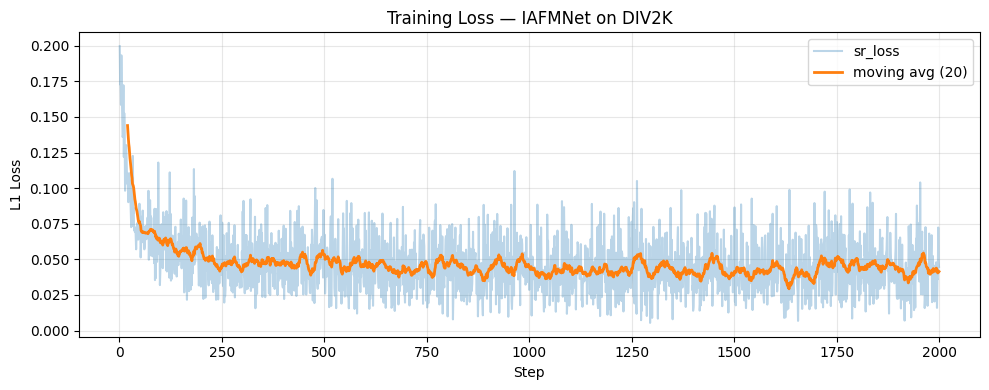

sr_loss: 0.1997 → 0.0054 (97.3% بهبود)


In [14]:
import matplotlib.pyplot as plt

steps = [h['step'] for h in history]
sr_losses = [h['sr'] for h in history]

plt.figure(figsize=(10, 4))
plt.plot(steps, sr_losses, alpha=0.3, label='sr_loss')
window = 20
if len(sr_losses) > window:
    avg = np.convolve(sr_losses, np.ones(window)/window, mode='valid')
    plt.plot(steps[window-1:], avg, linewidth=2, label=f'moving avg ({window})')
plt.xlabel('Step')
plt.ylabel('L1 Loss')
plt.title('Training Loss — IAFMNet on DIV2K')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f'sr_loss: {sr_losses[0]:.4f} → {best_loss:.4f} ({(1-best_loss/sr_losses[0])*100:.1f}% بهبود)')

## ۵. تست روی عکس واقعی DIV2K

HR: 2040x1404
LR: 510x351


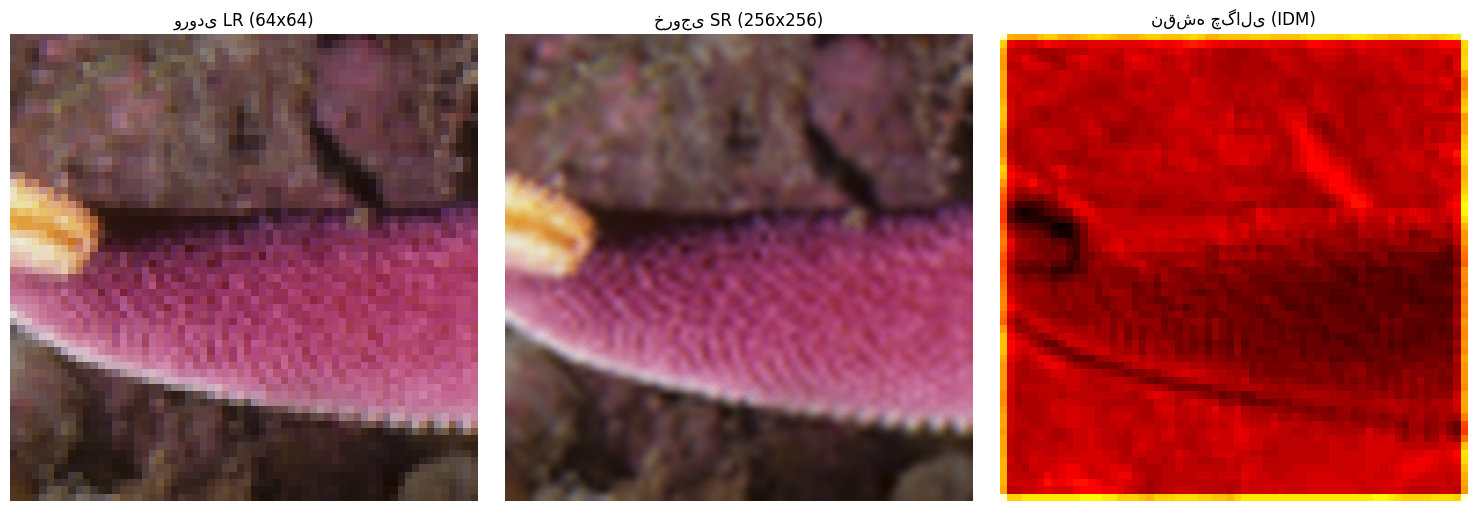

✅ خروجی SR از مدل آموزش‌دیده روی DIV2K


In [16]:
model.eval()

hr_path = Path('data/div2k/DIV2K_train_HR/0001.png')
lr_path = Path('data/div2k/DIV2K_train_LR_bicubic/X4/0001x4.png')
hr = np.array(cv2.imread(str(hr_path), cv2.IMREAD_COLOR))[:, :, ::-1]
lr = np.array(cv2.imread(str(lr_path), cv2.IMREAD_COLOR))[:, :, ::-1]
print(f'HR: {hr.shape[1]}x{hr.shape[0]}')
print(f'LR: {lr.shape[1]}x{lr.shape[0]}')

y, x = min(100, lr.shape[0]-64), min(100, lr.shape[1]-64)
lr_crop = lr[y:y+64, x:x+64]

with torch.no_grad():
    # Use .copy() to ensure the numpy array is contiguous in memory
    t = torch.from_numpy(lr_crop.copy()).permute(2, 0, 1).float().unsqueeze(0) / 255
    sr, idm = model(t)

sr_np = (sr[0].permute(1, 2, 0).numpy() * 255).clip(0, 255).astype(np.uint8)
idm_np = (idm[0, 0].numpy() * 255).clip(0, 255).astype(np.uint8)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(lr_crop)
axes[0].set_title(f'ورودی LR ({lr_crop.shape[1]}x{lr_crop.shape[0]})')
axes[1].imshow(sr_np)
axes[1].set_title(f'خروجی SR ({sr_np.shape[1]}x{sr_np.shape[0]})')
axes[2].imshow(idm_np, cmap='hot')
axes[2].set_title('نقشه چگالی (IDM)')
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()
print('✅ خروجی SR از مدل آموزش‌دیده روی DIV2K')

## ۶. اینترفیس وب (Gradio)
عکس آپلود کن → خروجی SR بگیر

بعد اجرا: `http://localhost:7860`

In [ ]:
import gradio as gr

model.eval()

def super_resolve(image):
    h, w = image.shape[:2]
    ph, pw = (4-h%4)%4, (4-w%4)%4
    if ph or pw:
        image = np.pad(image, [(0,ph),(0,pw),(0,0)], mode='reflect')
    with torch.no_grad():
        t = torch.from_numpy(image).permute(2, 0, 1).float().unsqueeze(0) / 255
        sr, idm = model(t)
    sr_np = (sr[0].permute(1, 2, 0).numpy() * 255).clip(0, 255).astype(np.uint8)[:h*4, :w*4]
    idm_np = (idm[0, 0].numpy() * 255).clip(0, 255).astype(np.uint8)
    return sr_np, idm_np

with gr.Blocks(title='IAFMNet SR') as demo:
    gr.Markdown('# 🖼️ IAFMNet Super-Resolution')
    gr.Markdown('عکس کم‌کیفیت آپلود کن → خروجی x4 واضح بگیر')
    with gr.Row():
        inp = gr.Image(label='ورودی', type='numpy')
        with gr.Column():
            out_sr = gr.Image(label='خروجی SR x4', type='numpy')
            out_idm = gr.Image(label='نقشه چگالی', type='numpy')
    gr.Button('⚡ Super-Resolve').click(super_resolve, inp, [out_sr, out_idm])

demo.launch(server_name='0.0.0.0', server_port=7860, share=False)